In [1]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
from pathlib import Path

file_path = Path(
    "/content/drive/MyDrive/iowa_liquor_sales_clean.parquet"
)

iowa_liquor_data = pd.read_parquet(file_path, engine="pyarrow")

print(iowa_liquor_data.shape)
iowa_liquor_data.head()

Mounted at /content/drive
(11889904, 23)


,invoice_id,ordered_on,store_no,store_name,store_address,store_city,store_zip_code,county_fips_code,county_name,category_code,...,item_no,im_desc,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sales_bottles,sales_dollars,sales_liters,sales_gallons
0,INV-43468400001,2022-01-02,2536,HY-VEE / PLEASANT HILL,4815 MAPLE DRIVE,PLEASANT HILL,50317.0,19153.0,POLK,1032100.0,...,34001,ABSOLUT SWEDISH VODKA 80PRF MINI,10,50,NaN,NaN,10,118.80,0.5,0.13
1,INV-43468400002,2022-01-02,2536,HY-VEE / PLEASANT HILL,4815 MAPLE DRIVE,PLEASANT HILL,50317.0,19153.0,POLK,1081300.0,...,71886,AMARETTO E DOLCE,12,750,NaN,NaN,12,60.12,9.0,2.37
2,INV-43468400003,2022-01-02,2536,HY-VEE / PLEASANT HILL,4815 MAPLE DRIVE,PLEASANT HILL,50317.0,19153.0,POLK,1082000.0,...,64138,DISARONNO AMARETTO,6,1750,NaN,NaN,6,252.12,10.5,2.77
3,INV-43468400004,2022-01-02,2536,HY-VEE / PLEASANT HILL,4815 MAPLE DRIVE,PLEASANT HILL,50317.0,19153.0,POLK,1031100.0,...,36908,MCCORMICK 80PRF VODKA PET,6,1750,NaN,NaN,12,134.52,21.0,5.54
4,INV-43468400005,2022-01-02,2536,HY-VEE / PLEASANT HILL,4815 MAPLE DRIVE,PLEASANT HILL,50317.0,19153.0,POLK,1031200.0,...,39492,NEW AMSTERDAM PINK WHITNEY,12,750,NaN,NaN,12,135.00,9.0,2.37


In [2]:
file_path = Path(
    "/content/drive/MyDrive/iowa_income_bracket_2024.csv"
)

iowa_county_data = pd.read_csv(file_path, engine="pyarrow")
iowa_county_data["location_name"] = iowa_county_data["location_name"].str.upper()
iowa_county_data = iowa_county_data.rename(columns={"location_name": "county_name", "value": "avg_income",
                                                    "income_group_jenks": "income_level"})

print(iowa_county_data.shape)
iowa_county_data

(99, 3)


,county_name,avg_income,income_level
0,DECATUR,46134,Low
1,WAPELLO,48623,Low
2,VAN BUREN,50427,Low
3,APPANOOSE,50647,Low
4,MARSHALL,51945,Low
...,...,...,...
94,WASHINGTON,84539,High
95,DALLAS,85124,High
96,CHEROKEE,86904,High
97,CHICKASAW,96643,High


In [3]:
category_groups = {
    # Tequila and mezcal
    "100% AGAVE TEQUILA": "TEQUILA & MEZCAL",
    "MIXTO TEQUILA": "TEQUILA & MEZCAL",
    "MEZCAL": "TEQUILA & MEZCAL",

    # Rum
    "AGED DARK RUM": "RUM",
    "FLAVORED RUM": "RUM",
    "GOLD RUM": "RUM",
    "SPICED RUM": "RUM",
    "WHITE RUM": "RUM",

    # Brandy
    "AMERICAN BRANDIES": "BRANDY",
    "IMPORTED BRANDIES": "BRANDY",

    # Gin
    "AMERICAN DRY GINS": "GIN",
    "AMERICAN SLOE GINS": "GIN",
    "FLAVORED GIN": "GIN",
    "IMPORTED DRY GINS": "GIN",
    "IMPORTED GINS": "GIN",

    # Vodka
    "AMERICAN VODKAS": "VODKA",
    "AMERICAN FLAVORED VODKA": "VODKA",
    "IMPORTED VODKAS": "VODKA",
    "IMPORTED FLAVORED VODKA": "VODKA",

    # Whiskey
    "BLENDED WHISKIES": "WHISKEY",
    "BOTTLED IN BOND BOURBON": "WHISKEY",
    "CANADIAN WHISKIES": "WHISKEY",
    "CORN WHISKIES": "WHISKEY",
    "IMPORTED WHISKIES": "WHISKEY",
    "IRISH WHISKIES": "WHISKEY",
    "SCOTCH WHISKIES": "WHISKEY",
    "SINGLE BARREL BOURBON WHISKIES": "WHISKEY",
    "SINGLE MALT SCOTCH": "WHISKEY",
    "STRAIGHT BOURBON WHISKIES": "WHISKEY",
    "STRAIGHT RYE WHISKIES": "WHISKEY",
    "TENNESSEE WHISKIES": "WHISKEY",

    # Liqueurs and schnapps
    "AMERICAN CORDIALS & LIQUEUR": "LIQUEURS & SCHNAPPS",
    "AMERICAN CORDIALS & LIQUEURS": "LIQUEURS & SCHNAPPS",
    "AMERICAN SCHNAPPS": "LIQUEURS & SCHNAPPS",
    "COFFEE LIQUEURS": "LIQUEURS & SCHNAPPS",
    "CREAM LIQUEURS": "LIQUEURS & SCHNAPPS",
    "IMPORTED CORDIALS & LIQUEUR": "LIQUEURS & SCHNAPPS",
    "IMPORTED CORDIALS & LIQUEURS": "LIQUEURS & SCHNAPPS",
    "IMPORTED SCHNAPPS": "LIQUEURS & SCHNAPPS",
    "TRIPLE SEC": "LIQUEURS & SCHNAPPS",
    "WHISKEY LIQUEUR": "LIQUEURS & SCHNAPPS",

    # Premixed drinks
    "COCKTAILS/RTD": "COCKTAILS & RTD",

    # Neutral grain spirits
    "NEUTRAL GRAIN SPIRITS": "NEUTRAL GRAIN SPIRITS",
    "NEUTRAL GRAIN SPIRITS FLAVORED": "NEUTRAL GRAIN SPIRITS",

    # Specialty products
    "AMERICAN DISTILLED SPIRIT SPECIALTY": "SPECIALTY & OTHER",
    "AMERICAN DISTILLED SPIRITS SPECIALTY": "SPECIALTY & OTHER",
    "DISTILLED SPIRITS SPECIALTY": "SPECIALTY & OTHER",
    "IMPORTED DISTILLED SPIRIT SPECIALTY": "SPECIALTY & OTHER",
    "IMPORTED DISTILLED SPIRITS SPECIALTY": "SPECIALTY & OTHER",
    "SPECIAL ORDER ITEMS": "SPECIALTY & OTHER",
    "TEMPORARY & SPECIALTY PACKAGES": "SPECIALTY & OTHER"
}

iowa_liquor_data["category_group"] = (
    iowa_liquor_data["category_name"]
    .str.strip()
    .str.upper()
    .map(category_groups)
)

sales_by_county_group = (
    iowa_liquor_data
    .groupby(["county_name", "category_group"], as_index=False)
    .agg(
        total_sales_dollars=("sales_dollars", "sum"),
        total_sales_liters=("sales_liters", "sum")
    )
)

print(sales_by_county_group.shape)
sales_by_county_group.head()

(990, 4)


,county_name,category_group,total_sales_dollars,total_sales_liters
0,ADAIR,BRANDY,40732.54,1879.940
1,ADAIR,COCKTAILS & RTD,36349.15,3907.645
2,ADAIR,GIN,15563.45,816.895
3,ADAIR,LIQUEURS & SCHNAPPS,463913.87,13444.730
4,ADAIR,NEUTRAL GRAIN SPIRITS,42051.30,1106.600


In [4]:
sales_by_county_group["dollars_proportion"] = (
    sales_by_county_group["total_sales_dollars"]
    / sales_by_county_group.groupby("county_name")["total_sales_dollars"].transform("sum")
)

sales_by_county_group["liters_proportion"] = (
    sales_by_county_group["total_sales_liters"]
    / sales_by_county_group.groupby("county_name")["total_sales_liters"].transform("sum")
)

print(sales_by_county_group.shape)
sales_by_county_group.head(11)

(990, 6)


,county_name,category_group,total_sales_dollars,total_sales_liters,dollars_proportion,liters_proportion
0,ADAIR,BRANDY,40732.54,1879.940,0.016262,0.014685
1,ADAIR,COCKTAILS & RTD,36349.15,3907.645,0.014512,0.030525
2,ADAIR,GIN,15563.45,816.895,0.006214,0.006381
3,ADAIR,LIQUEURS & SCHNAPPS,463913.87,13444.730,0.185215,0.105026
4,ADAIR,NEUTRAL GRAIN SPIRITS,42051.30,1106.600,0.016789,0.008644
5,ADAIR,RUM,202810.94,12807.855,0.080971,0.100051
6,ADAIR,SPECIALTY & OTHER,99532.44,2469.490,0.039738,0.019291
7,ADAIR,TEQUILA & MEZCAL,107501.59,3139.475,0.042919,0.024525
8,ADAIR,VODKA,519213.21,42146.345,0.207293,0.329233
9,ADAIR,WHISKEY,977058.83,46294.805,0.390086,0.361639


In [5]:
liquor_income_data = sales_by_county_group.merge(
    iowa_county_data[["county_name", "avg_income", "income_level"]],
    on="county_name",
    how="left",
    validate="many_to_one"
)


print(liquor_income_data.shape)
liquor_income_data.head()

(990, 8)


,county_name,category_group,total_sales_dollars,total_sales_liters,dollars_proportion,liters_proportion,avg_income,income_level
0,ADAIR,BRANDY,40732.54,1879.940,0.016262,0.014685,76983,Middle
1,ADAIR,COCKTAILS & RTD,36349.15,3907.645,0.014512,0.030525,76983,Middle
2,ADAIR,GIN,15563.45,816.895,0.006214,0.006381,76983,Middle
3,ADAIR,LIQUEURS & SCHNAPPS,463913.87,13444.730,0.185215,0.105026,76983,Middle
4,ADAIR,NEUTRAL GRAIN SPIRITS,42051.30,1106.600,0.016789,0.008644,76983,Middle


In [6]:
import plotly.express as px

county_preferences = (
    liquor_income_data
    .pivot_table(
        index=["county_name", "avg_income", "income_level"],
        columns="category_group",
        values="liters_proportion",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

county_preferences.head()

category_group,county_name,avg_income,income_level,BRANDY,COCKTAILS & RTD,GIN,LIQUEURS & SCHNAPPS,NEUTRAL GRAIN SPIRITS,RUM,SPECIALTY & OTHER,TEQUILA & MEZCAL,VODKA,WHISKEY
0,ADAIR,76983,Middle,0.014685,0.030525,0.006381,0.105026,0.008644,0.100051,0.019291,0.024525,0.329233,0.361639
1,ADAMS,63791,Middle,0.020452,0.033629,0.027922,0.133866,0.003701,0.059910,0.058550,0.033393,0.232440,0.396136
2,ALLAMAKEE,58705,Low,0.037560,0.037170,0.010903,0.141238,0.006415,0.139608,0.020718,0.020007,0.284601,0.301780
3,APPANOOSE,50647,Low,0.010616,0.046942,0.011760,0.167023,0.009061,0.117118,0.021734,0.024341,0.295100,0.296305
4,AUDUBON,67931,Middle,0.025612,0.028998,0.015680,0.104683,0.003507,0.147459,0.025914,0.020263,0.313395,0.314488


In [7]:
category_columns = [
    column for column in county_preferences.columns
    if column not in ["county_name", "avg_income", "income_level"]
]

chart_data = county_preferences.melt(
    id_vars=["county_name", "avg_income", "income_level"],
    value_vars=category_columns,
    var_name="category_group",
    value_name="liter_share"
)

income_preference = (
    chart_data
    .groupby(
        ["income_level", "category_group"],
        as_index=False
    )
    .agg(
        avg_liter_share=("liter_share", "mean"),
        county_count=("county_name", "nunique")
    )
)

income_order = (
    county_preferences
    .groupby("income_level")["avg_income"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

In [8]:
import statsmodels.api as sm
import numpy as np
from statsmodels.stats.multitest import multipletests

analysis_data = liquor_income_data.copy()

# Standardize income
analysis_data["income_z"] = (
    analysis_data["avg_income"]
    - analysis_data["avg_income"].mean()
) / analysis_data["avg_income"].std()

results = []

for category, group in analysis_data.groupby("category_group"):
    valid = group.dropna(subset=["liters_proportion", "income_z"])

    if (
        len(valid) >= 3
        and valid["liters_proportion"].nunique() > 1
        and valid["income_z"].nunique() > 1
    ):
        X = sm.add_constant(valid["income_z"])

        # Ordinary least-squares regression with robust standard errors
        model = sm.OLS(
            valid["liters_proportion"],
            X
        ).fit(cov_type="HC3")

        coefficient = model.params["income_z"]
        p_value = model.pvalues["income_z"]
        confidence_low, confidence_high = model.conf_int().loc["income_z"]
        r_squared = model.rsquared

    else:
        coefficient = np.nan
        p_value = np.nan
        confidence_low = np.nan
        confidence_high = np.nan
        r_squared = np.nan

    results.append({
        "category_group": category,
        "income_coefficient": coefficient,
        "ci_low": confidence_low,
        "ci_high": confidence_high,
        "p_value": p_value,
        "county_count": len(valid),
        "r_squared": r_squared
    })

regression_results = pd.DataFrame(results)

valid_p = regression_results["p_value"].notna()

regression_results.loc[valid_p, "adjusted_p_value"] = multipletests(
    regression_results.loc[valid_p, "p_value"],
    method="fdr_bh"
)[1]

regression_results["significant"] = (
    regression_results["adjusted_p_value"] < 0.05
)

regression_results = regression_results.sort_values("adjusted_p_value")
regression_results

,category_group,income_coefficient,ci_low,ci_high,p_value,county_count,r_squared,adjusted_p_value,significant
4,NEUTRAL GRAIN SPIRITS,-0.000680,-0.001132,-0.000229,0.003158,99,0.111134,0.031579,True
3,LIQUEURS & SCHNAPPS,-0.004648,-0.008443,-0.000854,0.016359,99,0.059306,0.081797,False
2,GIN,0.000557,-0.000917,0.002032,0.459001,99,0.007061,0.757469,False
0,BRANDY,-0.000540,-0.001893,0.000812,0.433388,99,0.003131,0.757469,False
6,SPECIALTY & OTHER,-0.001413,-0.004292,0.001466,0.335963,99,0.012232,0.757469,False
5,RUM,0.001923,-0.002367,0.006212,0.379703,99,0.009591,0.757469,False
7,TEQUILA & MEZCAL,0.000803,-0.002259,0.003865,0.607179,99,0.002758,0.757469,False
8,VODKA,0.001758,-0.006643,0.010159,0.681722,99,0.002562,0.757469,False
9,WHISKEY,0.002364,-0.005697,0.010424,0.565476,99,0.003006,0.757469,False
1,COCKTAILS & RTD,-0.000122,-0.002724,0.002479,0.926561,99,0.000152,0.926561,False


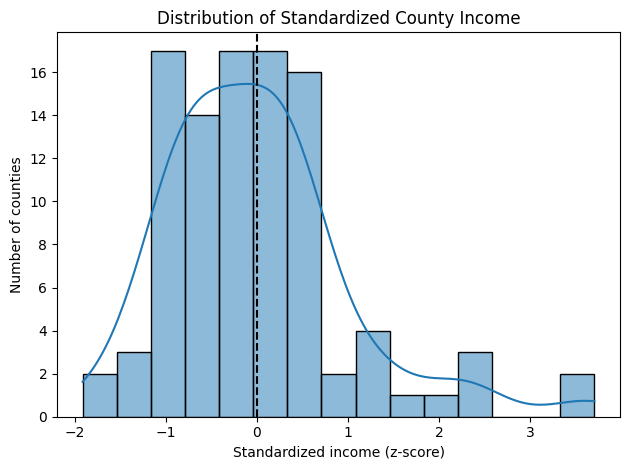

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

county_income = (
    analysis_data
    .drop_duplicates(subset="county_name")
)

sns.histplot(
    data=county_income,
    x="income_z",
    bins=15,
    kde=True
)

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Standardized income (z-score)")
plt.ylabel("Number of counties")
plt.title("Distribution of Standardized County Income")
plt.tight_layout()
plt.show()

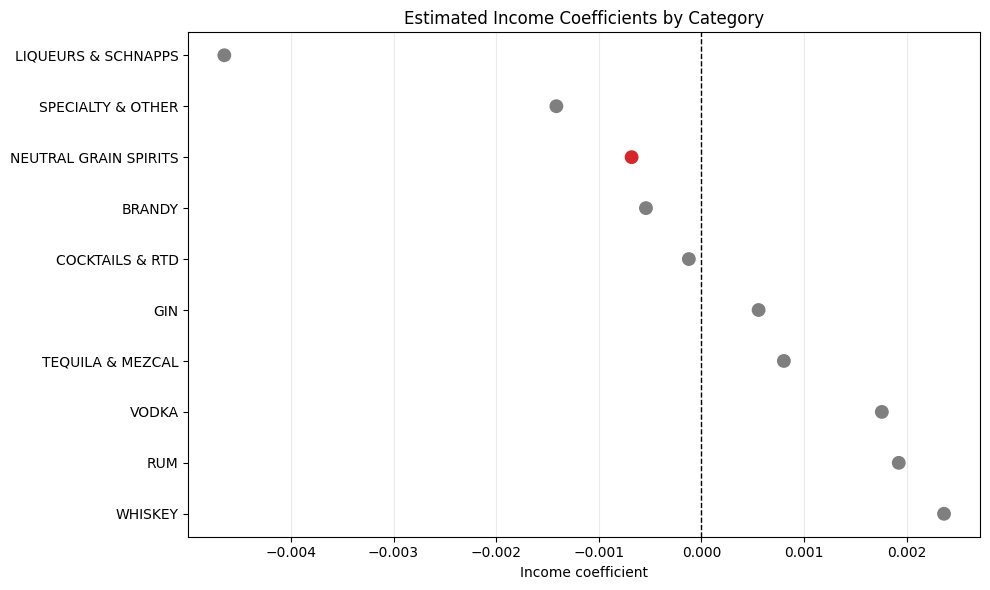

In [11]:
plot_results = regression_results.sort_values("income_coefficient", ascending=False)
colors = np.where(plot_results["significant"], "#d62728", "#7f7f7f")
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    plot_results["income_coefficient"],
    plot_results["category_group"],
    c=colors,
    s=80,
    zorder=3
)

ax.axvline(0, color="black", linestyle="--", linewidth=1)

ax.set(
    xlabel="Income coefficient",
    ylabel="",
    title="Estimated Income Coefficients by Category"
)

ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

In [13]:
fig = px.bar(
    income_preference,
    x="income_level",
    y="avg_liter_share",
    color="category_group",
    category_orders={
        "income_level": income_order
    },
    labels={
        "income_level": "Income level",
        "avg_liter_share": "Share of liters sold",
        "category_group": "Liquor category",
        "county_count": "Counties"
    },
    hover_data={
        "avg_liter_share": ":.2f",
        "county_count": True
    },
    title="Liquor Preferences by County Income Level"
)

fig.update_layout(
    barmode="stack",
    yaxis={"range": [0, 1]},
    xaxis_title="County income level",
    yaxis_title="Average share of liters sold",
    legend_title="Liquor category"
)

fig.show()